# The context of the problem

There is a huge demand for used cars in the Indian Market today. As sales of new cars have slowed down in the recent past, the pre-owned car market has continued to grow over the past years and is larger than the new car market now. Cars4U is a budding tech start-up that aims to find footholes in this market.

In 2018-19, while new car sales were recorded at 3.6 million units, around 4 million second-hand cars were bought and sold. There is a slowdown in new car sales and that could mean that the demand is shifting towards the pre-owned market. In fact, some car sellers replace their old cars with pre-owned cars instead of buying new ones. Unlike new cars, where price and supply are fairly deterministic and managed by OEMs (Original Equipment Manufacturer / except for dealership level discounts which come into play only in the last stage of the customer journey), used cars are very different beasts with huge uncertainty in both pricing and supply. Keeping this in mind, the pricing scheme of these used cars becomes important in order to grow in the market.

As a senior data scientist at Cars4U, you have to come up with a pricing model that can effectively predict the price of used cars and can help the business in devising profitable strategies using differential pricing. For example, if the business knows the market price, it will never sell anything below it.

# Objective

To explore and visualize the dataset, build a linear regression model to predict the prices of used cars, and generate a set of insights and recommendations that will help the business

# Data description

- S.No.: Serial number
- Name: Name of the car which includes brand name and model name
- Location: Location in which the car is being sold or is available for purchase (cities)
- Year: Manufacturing year of the car
- Kilometers_driven: The total kilometers driven in the car by the previous owner(s) in km
- Fuel_Type: The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)
- Transmission: The type of transmission used by the car (Automatic/Manual)
- Owner: Type of ownership
- Mileage: The standard mileage offered by the car company in kmpl or km/kg
- Engine: The displacement volume of the engine in CC
- Power: The maximum power of the engine in bhp
- Seats: The number of seats in the car
- New_Price: The price of a new car of the same model in INR Lakhs (1 Lakh = 100,000 INR)
- Price: The price of the used car in INR Lakhs

In [1]:
# this will help in making the Python code more structured automatically (good coding practice)
%reload_ext nb_black

import matplotlib.pyplot as plt

%matplotlib inline

import pandas as pd
import numpy as np

import seaborn as sns

sns.set(color_codes=True)

# removes the no. of columns displayed in a column
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# importing necessary packages for the SLR model from SLR
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings

warnings.filterwarnings("ignore")

<IPython.core.display.Javascript object>

In [2]:
car_data = pd.read_csv("used_cars_data.csv")
print(
    f"There are {car_data.shape[0]} rows and {car_data.shape[1]} columns in the dataset"
)

There are 7253 rows and 14 columns in the dataset


<IPython.core.display.Javascript object>

In [3]:
data = car_data.copy()  # making a copy of the orignal set

<IPython.core.display.Javascript object>

In [4]:
# let us take a glance at a few of the samples in the data to see what is in it

data.sample(10)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
2134,2134,Toyota Fortuner 2.8 2WD AT,Pune,2017,29000,Diesel,Automatic,First,12.9 kmpl,2755 CC,174.5 bhp,7.0,38.11 Lakh,31.00
1765,1765,Maruti Ritz LDi,Jaipur,2011,79232,Diesel,Manual,First,21.1 kmpl,1248 CC,73.9 bhp,5.0,NaN,2.90
6073,6073,Hyundai Verna 1.6 SX VTVT,Mumbai,2014,21000,Petrol,Manual,First,17.01 kmpl,1591 CC,121.3 bhp,5.0,NaN,NaN
3685,3685,BMW 5 Series 530d Highline Sedan,Ahmedabad,2010,68000,Diesel,Automatic,First,11.5 kmpl,2993 CC,235 bhp,5.0,NaN,18.00
1802,1802,Skoda Laura 1.8 TSI Ambiente,Bangalore,2011,46000,Petrol,Manual,First,13.4 kmpl,1798 CC,157.8 bhp,5.0,NaN,5.50
3250,3250,Toyota Etios G SP,Bangalore,2013,132000,Petrol,Manual,First,16.78 kmpl,1496 CC,88.73 bhp,5.0,NaN,4.70
966,966,Mercedes-Benz CLA 200 CDI Sport,Coimbatore,2017,13689,Diesel,Automatic,First,17.9 kmpl,2143 CC,136 bhp,5.0,NaN,28.25
6152,6152,Maruti A-Star Zxi,Chennai,2009,60000,Petrol,Manual,Third,19.0 kmpl,998 CC,66.1 bhp,5.0,NaN,NaN
5673,5673,Mercedes-Benz CLA 200 D Sport Edition,Coimbatore,2019,15976,Diesel,Automatic,First,17.9 kmpl,2143 CC,136 bhp,5.0,NaN,36.76
3062,3062,Audi Q7 3.0 TDI Quattro Premium Plus,Coimbatore,2014,51076,Diesel,Automatic,First,12.07 kmpl,2967 CC,241.4 bhp,7.0,NaN,34.88


<IPython.core.display.Javascript object>

### Observations and quality

- S.no. looks like a column that can be removed
- There are a lot of information in the name column, looks like it needs to be processed
- Mileage, engine, power has some text data (units) in them that need to b worked upon
- The new price column has missing values that need to be processed and worked upon

In [5]:
# dropping the column S.no.
data.drop("S.No.", axis="columns", inplace=True)

<IPython.core.display.Javascript object>

In [6]:
data.info()  # to get some more insights on dtypes and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Year               7253 non-null   int64  
 3   Kilometers_Driven  7253 non-null   int64  
 4   Fuel_Type          7253 non-null   object 
 5   Transmission       7253 non-null   object 
 6   Owner_Type         7253 non-null   object 
 7   Mileage            7251 non-null   object 
 8   Engine             7207 non-null   object 
 9   Power              7078 non-null   object 
 10  Seats              7200 non-null   float64
 11  New_Price          1006 non-null   object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB


<IPython.core.display.Javascript object>

### Observations

- The Mileage, power, engine, new_price are object whereas they should be int

In [7]:
# checking for the duplicated values
# there is one duplicated value
data.duplicated().sum()

1

<IPython.core.display.Javascript object>

In [8]:
data[data.duplicated(keep=False) == True]  # finding that duplicate value

# both the cars have the same data, one can be dropped

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
6498,Honda City 1.5 E MT,Mumbai,2010,52000,Petrol,Manual,First,17.0 kmpl,1497 CC,118 bhp,5.0,NaN,NaN
6582,Honda City 1.5 E MT,Mumbai,2010,52000,Petrol,Manual,First,17.0 kmpl,1497 CC,118 bhp,5.0,NaN,NaN


<IPython.core.display.Javascript object>

In [9]:
data.drop(6582, inplace=True)

<IPython.core.display.Javascript object>

##  Data Preprocessing

In [10]:
# Let's process the Mileage, Engine, Power, and New_Price columns to extract numerical values from them.

# for convince changing the column names to lowercase

data.columns = data.columns.str.lower()

<IPython.core.display.Javascript object>

In [11]:
data["mileage"].head(10)
# as we can see the column has units like km/kg, kmpl
# kmpl is used in cars with fueltype as petrol diesel
# kmkg is used in cars with fuel type as gas (CNG-LPG)

0    26.6 km/kg
1    19.67 kmpl
2     18.2 kmpl
3    20.77 kmpl
4     15.2 kmpl
5    21.1 km/kg
6    23.08 kmpl
7    11.36 kmpl
8    20.54 kmpl
9     22.3 kmpl
Name: mileage, dtype: object

<IPython.core.display.Javascript object>

In [12]:
data_mileage = data["mileage"].str.split(" ", expand=True)
data_mileage.head()

,0,1
0,26.6,km/kg
1,19.67,kmpl
2,18.2,kmpl
3,20.77,kmpl
4,15.2,kmpl


<IPython.core.display.Javascript object>

In [13]:
data["mileage_value"] = data_mileage[0].astype(float)

<IPython.core.display.Javascript object>

In [14]:
data["engine"].head(10)

0     998 CC
1    1582 CC
2    1199 CC
3    1248 CC
4    1968 CC
5     814 CC
6    1461 CC
7    2755 CC
8    1598 CC
9    1248 CC
Name: engine, dtype: object

<IPython.core.display.Javascript object>

In [15]:
data_engine = data["engine"].str.split(" ", expand=True)
data_engine.head()

,0,1
0,998,CC
1,1582,CC
2,1199,CC
3,1248,CC
4,1968,CC


<IPython.core.display.Javascript object>

In [16]:
data["engine_value"] = data_engine[0].astype(
    float
)  # adding just the numerical values to main data

<IPython.core.display.Javascript object>

In [17]:
# time to process power

data["power"].head()

0    58.16 bhp
1    126.2 bhp
2     88.7 bhp
3    88.76 bhp
4    140.8 bhp
Name: power, dtype: object

<IPython.core.display.Javascript object>

In [18]:
data_power = data["power"].str.split(" ", expand=True)
data_power.head()

,0,1
0,58.16,bhp
1,126.2,bhp
2,88.7,bhp
3,88.76,bhp
4,140.8,bhp


<IPython.core.display.Javascript object>

In [19]:
data_power[1].value_counts()  # to make sure we just have one unit in the data frame

bhp    7077
Name: 1, dtype: int64

<IPython.core.display.Javascript object>

In [20]:
data["power_value"] = data_power[0].astype(
    float
)  # adding just the numerical values to main data

<IPython.core.display.Javascript object>

In [21]:
data.info()  # checking if the things are going as per the code

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               7252 non-null   object 
 1   location           7252 non-null   object 
 2   year               7252 non-null   int64  
 3   kilometers_driven  7252 non-null   int64  
 4   fuel_type          7252 non-null   object 
 5   transmission       7252 non-null   object 
 6   owner_type         7252 non-null   object 
 7   mileage            7250 non-null   object 
 8   engine             7206 non-null   object 
 9   power              7077 non-null   object 
 10  seats              7199 non-null   float64
 11  new_price          1006 non-null   object 
 12  price              6019 non-null   float64
 13  mileage_value      7250 non-null   float64
 14  engine_value       7206 non-null   float64
 15  power_value        7077 non-null   float64
dtypes: float64(5), int64(2),

<IPython.core.display.Javascript object>

#### New price is the price of the a new car of the same model, let us extract the numerical value to see

In [22]:
data["new_price"].head(10)

0          NaN
1          NaN
2    8.61 Lakh
3          NaN
4          NaN
5          NaN
6          NaN
7      21 Lakh
8          NaN
9          NaN
Name: new_price, dtype: object

<IPython.core.display.Javascript object>

In [23]:
new_price_value = data["new_price"].str.split(" ", expand=True)
new_price_value.head()

,0,1
0,NaN,NaN
1,NaN,NaN
2,8.61,Lakh
3,NaN,NaN
4,NaN,NaN


<IPython.core.display.Javascript object>

In [24]:
new_price_value[
    1
].value_counts()  # so we have a challenge her, let us try to fix this by using a function

Lakh    986
Cr       20
Name: 1, dtype: int64

<IPython.core.display.Javascript object>

In [25]:
def new_price_to_num(new_price_val):
    if isinstance(new_price_val, str):
        multiplier = 1
        if new_price_val.endswith("Lakh"):
            multiplier = 1
        elif new_price_val.endswith("Cr"):
            multiplier = 100
        return float(new_price_val.replace(" Lakh", "").replace(" Cr", "")) * multiplier
    else:
        return np.nan

<IPython.core.display.Javascript object>

In [26]:
data["new_price_pro"] = data["new_price"].apply(new_price_to_num)

<IPython.core.display.Javascript object>

In [27]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price,mileage_value,engine_value,power_value,new_price_pro
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,26.60,998.0,58.16,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,19.67,1582.0,126.20,NaN
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,18.20,1199.0,88.70,8.61
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,20.77,1248.0,88.76,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,15.20,1968.0,140.80,NaN


<IPython.core.display.Javascript object>

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               7252 non-null   object 
 1   location           7252 non-null   object 
 2   year               7252 non-null   int64  
 3   kilometers_driven  7252 non-null   int64  
 4   fuel_type          7252 non-null   object 
 5   transmission       7252 non-null   object 
 6   owner_type         7252 non-null   object 
 7   mileage            7250 non-null   object 
 8   engine             7206 non-null   object 
 9   power              7077 non-null   object 
 10  seats              7199 non-null   float64
 11  new_price          1006 non-null   object 
 12  price              6019 non-null   float64
 13  mileage_value      7250 non-null   float64
 14  engine_value       7206 non-null   float64
 15  power_value        7077 non-null   float64
 16  new_price_pro      1006 

<IPython.core.display.Javascript object>

In [29]:
# let us drop the processed columns
data.drop(["new_price", "power", "engine", "mileage"], axis="columns", inplace=True)

<IPython.core.display.Javascript object>

In [30]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,NaN
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN


<IPython.core.display.Javascript object>

## feature engineering

In [31]:
data[
    "name"
].nunique()  # there are 2041 unique names, this could lead to curse of dimensionallity

2041

<IPython.core.display.Javascript object>

In [32]:
data["name"].head()  # we can split the data in the brand name and model name

0              Maruti Wagon R LXI CNG
1    Hyundai Creta 1.6 CRDi SX Option
2                        Honda Jazz V
3                   Maruti Ertiga VDI
4     Audi A4 New 2.0 TDI Multitronic
Name: name, dtype: object

<IPython.core.display.Javascript object>

In [33]:
data["brand"] = data["name"].apply(lambda x: x.split(" ")[0].lower())

<IPython.core.display.Javascript object>

In [34]:
data["model_name"] = data["name"].apply(lambda x: x.split(" ")[1].lower())

<IPython.core.display.Javascript object>

In [35]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,NaN,maruti,wagon
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,NaN,hyundai,creta
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61,honda,jazz
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,NaN,maruti,ertiga
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN,audi,a4


<IPython.core.display.Javascript object>

In [36]:
data["brand"].value_counts()

maruti           1444
hyundai          1340
honda             742
toyota            507
mercedes-benz     380
volkswagen        374
ford              351
mahindra          331
bmw               312
audi              285
tata              228
skoda             202
renault           170
chevrolet         151
nissan            117
land               67
jaguar             48
fiat               38
mitsubishi         36
mini               31
volvo              28
jeep               19
porsche            19
datsun             17
isuzu               5
force               3
bentley             2
hindustan           1
ambassador          1
opelcorsa           1
lamborghini         1
smart               1
Name: brand, dtype: int64

<IPython.core.display.Javascript object>

In [37]:
data["model_name"].value_counts()

swift      418
city       317
i20        303
innova     203
verna      200
          ... 
370z         1
1.4gsi       1
redi         1
venture      1
land         1
Name: model_name, Length: 218, dtype: int64

<IPython.core.display.Javascript object>

Checking on the missingness of the data

In [38]:
data.isnull().sum()

name                    0
location                0
year                    0
kilometers_driven       0
fuel_type               0
transmission            0
owner_type              0
seats                  53
price                1233
mileage_value           2
engine_value           46
power_value           175
new_price_pro        6246
brand                   0
model_name              0
dtype: int64

<IPython.core.display.Javascript object>

In [39]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,7252.0,2013.365830,3.254405,1996.00,2011.000,2014.00,2016.0000,2019.00
kilometers_driven,7252.0,58699.986900,84433.505524,171.00,34000.000,53429.00,73000.0000,6500000.00
seats,7199.0,5.279761,0.811709,0.00,5.000,5.00,5.0000,10.00
price,6019.0,9.479468,11.187917,0.44,3.500,5.64,9.9500,160.00
mileage_value,7250.0,18.141738,4.562492,0.00,15.170,18.16,21.1000,33.54
engine_value,7206.0,1616.590064,595.324779,72.00,1198.000,1493.00,1968.0000,5998.00
power_value,7077.0,112.764474,53.497297,34.20,75.000,94.00,138.1000,616.00
new_price_pro,1006.0,22.779692,27.759344,3.91,7.885,11.57,26.0425,375.00


<IPython.core.display.Javascript object>

- Kilometers_Driven values have an incredibly high range. We should check a few of the extreme values to get a sense of the data
- We have used cars being sold at less than a lakh INR and as high as 160 lakh INR, We might have to check for outliers to build a robust model
- The minimum mileage being 0 is also concerning. We'll have to check what is going on.
- Engine and Power mean and median values are not very different. Only someone with more domain knowledge would be able to comment further on these attributes.

In [40]:
data.sort_values(by=["kilometers_driven"], ascending=False).head()

# 65,00,0000 kms driven for a car built in 2017 does not go well, we might need to treat this outlier

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
2328,BMW X5 xDrive 30d M Sport,Chennai,2017,6500000,Diesel,Automatic,First,5.0,65.0,15.97,2993.0,258.00,NaN,bmw,x5
340,Skoda Octavia Ambition Plus 2.0 TDI AT,Kolkata,2013,775000,Diesel,Automatic,First,5.0,7.5,19.30,1968.0,141.00,NaN,skoda,octavia
1860,Volkswagen Vento Diesel Highline,Chennai,2013,720000,Diesel,Manual,First,5.0,5.9,20.54,1598.0,103.60,NaN,volkswagen,vento
358,Hyundai i10 Magna 1.2,Chennai,2009,620000,Petrol,Manual,First,5.0,2.7,20.36,1197.0,78.90,NaN,hyundai,i10
2823,Volkswagen Jetta 2013-2015 2.0L TDI Highline AT,Chennai,2015,480000,Diesel,Automatic,First,5.0,13.0,16.96,1968.0,138.03,NaN,volkswagen,jetta


<IPython.core.display.Javascript object>

In [41]:
data.sort_values(by=["kilometers_driven"], ascending=True).head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
1361,Maruti Alto 800 2016-2019 VXI,Mumbai,2019,171,Petrol,Manual,First,5.0,3.60,24.70,796.0,47.30,NaN,maruti,alto
5606,Maruti Wagon R ZXI AMT 1.2,Mumbai,2019,600,Petrol,Automatic,First,5.0,6.25,21.50,1197.0,81.80,6.80,maruti,wagon
2054,Maruti Ignis 1.2 Alpha,Mumbai,2017,1000,Petrol,Manual,First,5.0,6.36,20.89,1197.0,81.80,7.87,maruti,ignis
6201,Maruti Alto LXI,Kolkata,2019,1000,Petrol,Manual,First,5.0,NaN,24.70,796.0,47.30,3.99,maruti,alto
1598,Tata Xenon XT EX 4X2,Jaipur,2017,1000,Diesel,Manual,First,5.0,7.50,13.49,2179.0,138.03,NaN,tata,xenon


<IPython.core.display.Javascript object>

In [42]:
data.sort_values(by=["seats"], ascending=False).head(10)

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
6875,Toyota Qualis FS B3,Pune,2002,119613,Diesel,Manual,Second,10.0,NaN,13.10,2446.0,75.0,NaN,toyota,qualis
814,Toyota Qualis FS B2,Pune,2004,77757,Diesel,Manual,Second,10.0,3.50,13.10,2446.0,75.0,NaN,toyota,qualis
2267,Toyota Qualis RS E2,Pune,2004,215750,Diesel,Manual,Second,10.0,3.50,0.00,2446.0,NaN,NaN,toyota,qualis
6288,Chevrolet Tavera LS B3 10 Seats BSIII,Hyderabad,2005,150000,Diesel,Manual,Second,10.0,NaN,14.80,2499.0,80.0,NaN,chevrolet,tavera
6242,Tata Sumo EX 10/7 Str BSII,Chennai,2015,196000,Diesel,Manual,Second,10.0,NaN,12.20,1948.0,68.0,NaN,tata,sumo
1907,Toyota Qualis FS B3,Bangalore,2002,63000,Diesel,Manual,Third,10.0,3.65,13.10,2446.0,75.0,NaN,toyota,qualis
917,Tata Sumo DX,Mumbai,2013,20000,Diesel,Manual,First,10.0,5.25,14.07,1978.0,83.1,NaN,tata,sumo
2575,Chevrolet Tavera LS B3 10 Seats BSIII,Hyderabad,2015,120000,Diesel,Manual,First,10.0,5.50,14.80,2499.0,80.0,NaN,chevrolet,tavera
2312,Chevrolet Tavera LT 9 Str BS IV,Kolkata,2012,67132,Diesel,Manual,First,9.0,4.75,13.58,2499.0,78.0,NaN,chevrolet,tavera
2359,Mahindra Xylo D2 Maxx,Chennai,2016,150000,Diesel,Manual,First,9.0,4.50,14.95,2489.0,93.7,NaN,mahindra,xylo


<IPython.core.display.Javascript object>

In [43]:
data.sort_values(by=["seats"], ascending=True).head(10)

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,2012,125000,Petrol,Automatic,First,0.0,18.00,10.50,3197.0,NaN,NaN,audi,a4
926,Porsche Cayman 2009-2012 S,Hyderabad,2010,10000,Petrol,Manual,First,2.0,40.00,9.00,3436.0,NaN,NaN,porsche,cayman
134,Mercedes-Benz SLC 43 AMG,Kolkata,2017,13372,Petrol,Automatic,First,2.0,54.00,19.00,2996.0,362.07,95.04,mercedes-benz,slc
1078,Porsche Boxster S tiptronic,Kolkata,2015,10512,Petrol,Automatic,First,2.0,64.00,8.60,2706.0,265.00,NaN,porsche,boxster
798,Mercedes-Benz SLK-Class SLK 350,Bangalore,2015,10000,Petrol,Automatic,First,2.0,55.00,18.10,3498.0,306.00,NaN,mercedes-benz,slk-class
5781,Lamborghini Gallardo Coupe,Delhi,2011,6500,Petrol,Automatic,Third,2.0,120.00,6.40,5204.0,560.00,NaN,lamborghini,gallardo
5919,Jaguar F Type 5.0 V8 S,Hyderabad,2015,8000,Petrol,Automatic,First,2.0,100.00,12.50,5000.0,488.10,NaN,jaguar,f
4893,BMW Z4 2009-2013 Roadster 2.5i,Kochi,2018,9952,Petrol,Automatic,First,2.0,58.54,10.37,2979.0,306.00,NaN,bmw,z4
4722,Mercedes-Benz SL-Class SL 500,Kolkata,2010,35000,Petrol,Automatic,First,2.0,29.50,8.10,5461.0,387.30,NaN,mercedes-benz,sl-class
915,Smart Fortwo CDI AT,Pune,2008,103000,Diesel,Automatic,Second,2.0,3.00,0.00,799.0,NaN,NaN,smart,fortwo


<IPython.core.display.Javascript object>

In [44]:
data[data["name"].str.startswith("Audi A4")]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN,audi,a4
50,Audi A4 2.0 TDI 177 Bhp Premium Plus,Kochi,2015,13648,Diesel,Automatic,First,5.0,21.43,17.11,1968.0,174.33,NaN,audi,a4
65,Audi A4 2.0 TDI Multitronic,Jaipur,2012,65664,Diesel,Automatic,First,5.0,13.50,16.55,1968.0,140.00,NaN,audi,a4
103,Audi A4 3.0 TDI Quattro Premium,Kolkata,2010,30000,Diesel,Automatic,First,5.0,9.80,14.94,2967.0,241.40,NaN,audi,a4
150,Audi A4 2.0 TDI 177 Bhp Premium Plus,Coimbatore,2015,48214,Diesel,Automatic,First,5.0,23.32,17.11,1968.0,174.33,NaN,audi,a4
717,Audi A4 2.0 TDI 177 Bhp Premium Plus,Bangalore,2013,45979,Diesel,Automatic,Second,5.0,19.50,17.11,1968.0,174.33,NaN,audi,a4
853,Audi A4 2.0 TDI,Delhi,2011,46000,Diesel,Automatic,Second,5.0,10.99,16.55,1968.0,147.51,NaN,audi,a4
854,Audi A4 2.0 TDI,Kolkata,2012,47346,Diesel,Automatic,First,5.0,14.50,16.55,1968.0,147.51,NaN,audi,a4
874,Audi A4 2.0 TDI Multitronic,Ahmedabad,2011,59000,Diesel,Automatic,First,5.0,12.50,16.55,1968.0,140.00,NaN,audi,a4
964,Audi A4 2.0 TDI,Kolkata,2009,34000,Diesel,Automatic,First,5.0,9.95,16.55,1968.0,147.51,NaN,audi,a4


<IPython.core.display.Javascript object>

In [45]:
data.loc[3999, "seats"] = 5.0

<IPython.core.display.Javascript object>

In [46]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,NaN,maruti,wagon
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,NaN,hyundai,creta
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61,honda,jazz
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,NaN,maruti,ertiga
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN,audi,a4


<IPython.core.display.Javascript object>

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               7252 non-null   object 
 1   location           7252 non-null   object 
 2   year               7252 non-null   int64  
 3   kilometers_driven  7252 non-null   int64  
 4   fuel_type          7252 non-null   object 
 5   transmission       7252 non-null   object 
 6   owner_type         7252 non-null   object 
 7   seats              7199 non-null   float64
 8   price              6019 non-null   float64
 9   mileage_value      7250 non-null   float64
 10  engine_value       7206 non-null   float64
 11  power_value        7077 non-null   float64
 12  new_price_pro      1006 non-null   float64
 13  brand              7252 non-null   object 
 14  model_name         7252 non-null   object 
dtypes: float64(6), int64(2), object(7)
memory usage: 1.1+ MB


<IPython.core.display.Javascript object>

In [48]:
num_to_display = 10
for colname in data.dtypes[data.dtypes == "object"].index:
    val_counts = data[colname].value_counts(dropna=False)
    print(val_counts[:num_to_display])

    if len(val_counts) > num_to_display:
        print(f"Only displaying first {num_to_display} of {len(val_counts)} values.")
    print("-" * 50, "\n")  # just for more space in between


Mahindra XUV500 W8 2WD        55
Maruti Swift VDI              49
Maruti Swift Dzire VDI        42
Honda City 1.5 S MT           39
Maruti Swift VDI BSIV         37
Toyota Fortuner 3.0 Diesel    35
Maruti Ritz VDi               35
Hyundai Grand i10 Sportz      32
Honda Amaze S i-Dtech         32
Honda City 1.5 V MT           32
Name: name, dtype: int64
Only displaying first 10 of 2041 values.
-------------------------------------------------- 

Mumbai        948
Hyderabad     876
Kochi         772
Coimbatore    772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Name: location, dtype: int64
Only displaying first 10 of 11 values.
-------------------------------------------------- 

Diesel      3852
Petrol      3324
CNG           62
LPG           12
Electric       2
Name: fuel_type, dtype: int64
-------------------------------------------------- 

Manual       5203
Automatic    2049
Name: transmission, dtype: int64
-------------

<IPython.core.display.Javascript object>

There are 2 electric cars in the dataset, that can be removed as this is very low for us to predict the price

In [49]:
data[data["fuel_type"] == "Electric"]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name
4446,Mahindra E Verito D4,Chennai,2016,50000,Electric,Automatic,First,5.0,13.00,NaN,72.0,41.0,13.58,mahindra,e
4904,Toyota Prius 2009-2016 Z4,Mumbai,2011,44000,Electric,Automatic,First,5.0,12.75,NaN,1798.0,73.0,NaN,toyota,prius


<IPython.core.display.Javascript object>

In [50]:
# checking used car price by brand
data.groupby(["brand"])["price"].mean().sort_values(ascending=False)

brand
lamborghini      120.000000
bentley           59.000000
porsche           48.348333
land              39.259500
jaguar            37.632250
mini              26.896923
mercedes-benz     26.809874
audi              25.537712
bmw               25.243146
volvo             18.802857
jeep              18.718667
isuzu             14.696667
toyota            11.580024
mitsubishi        11.058889
force              9.333333
mahindra           8.045919
skoda              7.559075
ford               6.889400
renault            5.799034
honda              5.411743
hyundai            5.343433
volkswagen         5.307270
nissan             4.738352
maruti             4.517267
tata               3.562849
fiat               3.269286
datsun             3.049231
chevrolet          3.044463
smart              3.000000
ambassador         1.350000
hindustan               NaN
opelcorsa               NaN
Name: price, dtype: float64

<IPython.core.display.Javascript object>

- The output is very close to our expectation (domain knowledge) in terms of brand order.
- The mean price of a used Lamborghini is 120 Lakhs and that of cars from other luxury brands follow in descending order.
- Towards the bottom end, we have the more budget-friendly brands.

# Visualization

In [51]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

<IPython.core.display.Javascript object>

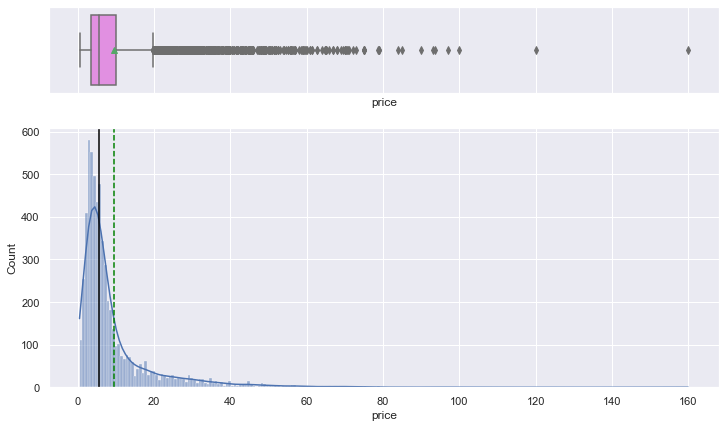

<IPython.core.display.Javascript object>

In [52]:
histogram_boxplot(
    data, "price", kde=True
)  # the distribution seemed to be highly skewed, using natural transformation

In [53]:
data["price_log"] = np.log(data["price"])

<IPython.core.display.Javascript object>

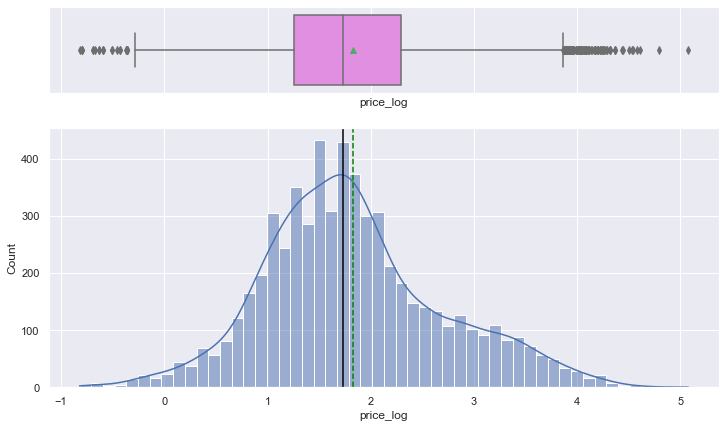

<IPython.core.display.Javascript object>

In [54]:
histogram_boxplot(
    data, "price_log", kde=True
)  # the distribution seemed to be highly skewed, using natural transformation

In [55]:
data["kilometers_driven_log"] = np.log(data["kilometers_driven"])

<IPython.core.display.Javascript object>

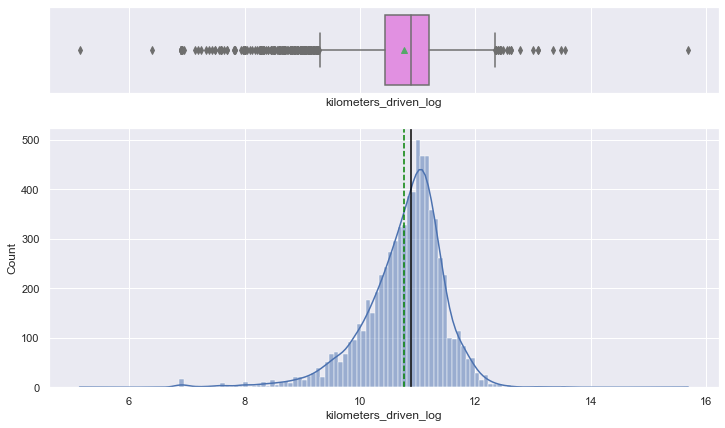

<IPython.core.display.Javascript object>

In [56]:
histogram_boxplot(data, "kilometers_driven_log", kde=True)

In [57]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

<IPython.core.display.Javascript object>

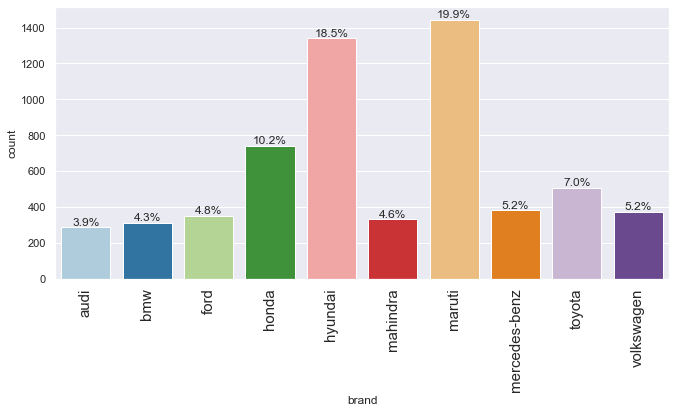

<IPython.core.display.Javascript object>

In [58]:
labeled_barplot(data, "brand", n=10, perc=True)

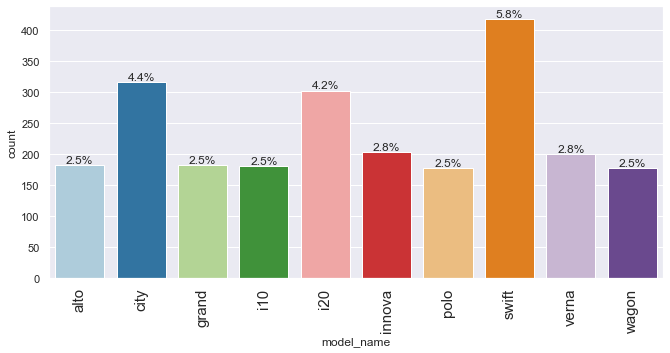

<IPython.core.display.Javascript object>

In [59]:
labeled_barplot(data, "model_name", perc=True, n=10)

In [60]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,NaN,maruti,wagon,0.559616,11.184421
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,NaN,hyundai,creta,2.525729,10.621327
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61,honda,jazz,1.504077,10.736397
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,NaN,maruti,ertiga,1.791759,11.373663
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN,audi,a4,2.875822,10.613246


<IPython.core.display.Javascript object>

In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7252 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   7252 non-null   object 
 1   location               7252 non-null   object 
 2   year                   7252 non-null   int64  
 3   kilometers_driven      7252 non-null   int64  
 4   fuel_type              7252 non-null   object 
 5   transmission           7252 non-null   object 
 6   owner_type             7252 non-null   object 
 7   seats                  7199 non-null   float64
 8   price                  6019 non-null   float64
 9   mileage_value          7250 non-null   float64
 10  engine_value           7206 non-null   float64
 11  power_value            7077 non-null   float64
 12  new_price_pro          1006 non-null   float64
 13  brand                  7252 non-null   object 
 14  model_name             7252 non-null   object 
 15  pric

<IPython.core.display.Javascript object>

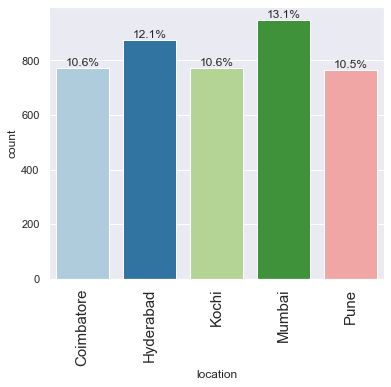

<IPython.core.display.Javascript object>

In [62]:
labeled_barplot(data, "location", perc=True, n=5)

### Bivariate analysis

<AxesSubplot:>

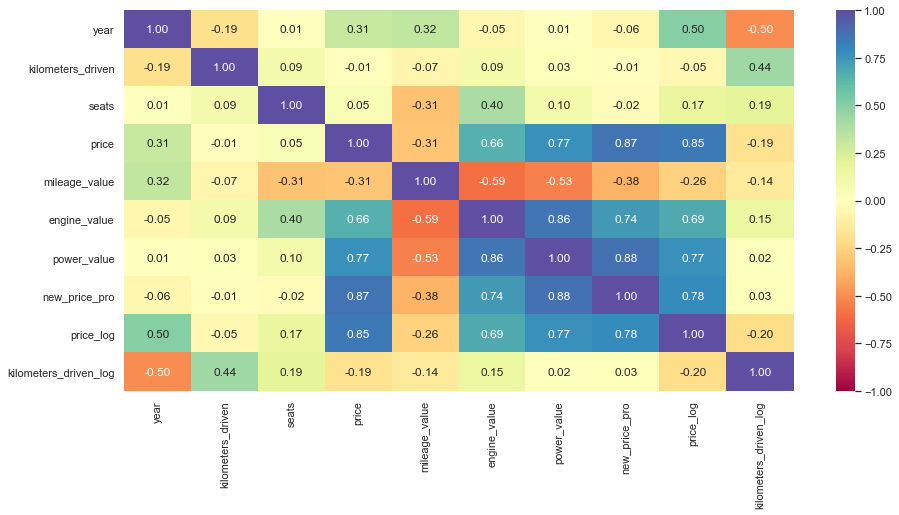

<IPython.core.display.Javascript object>

In [63]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

### Observations
- Power and engine are important predictors of price
- we need to figure out missing values in the new_price

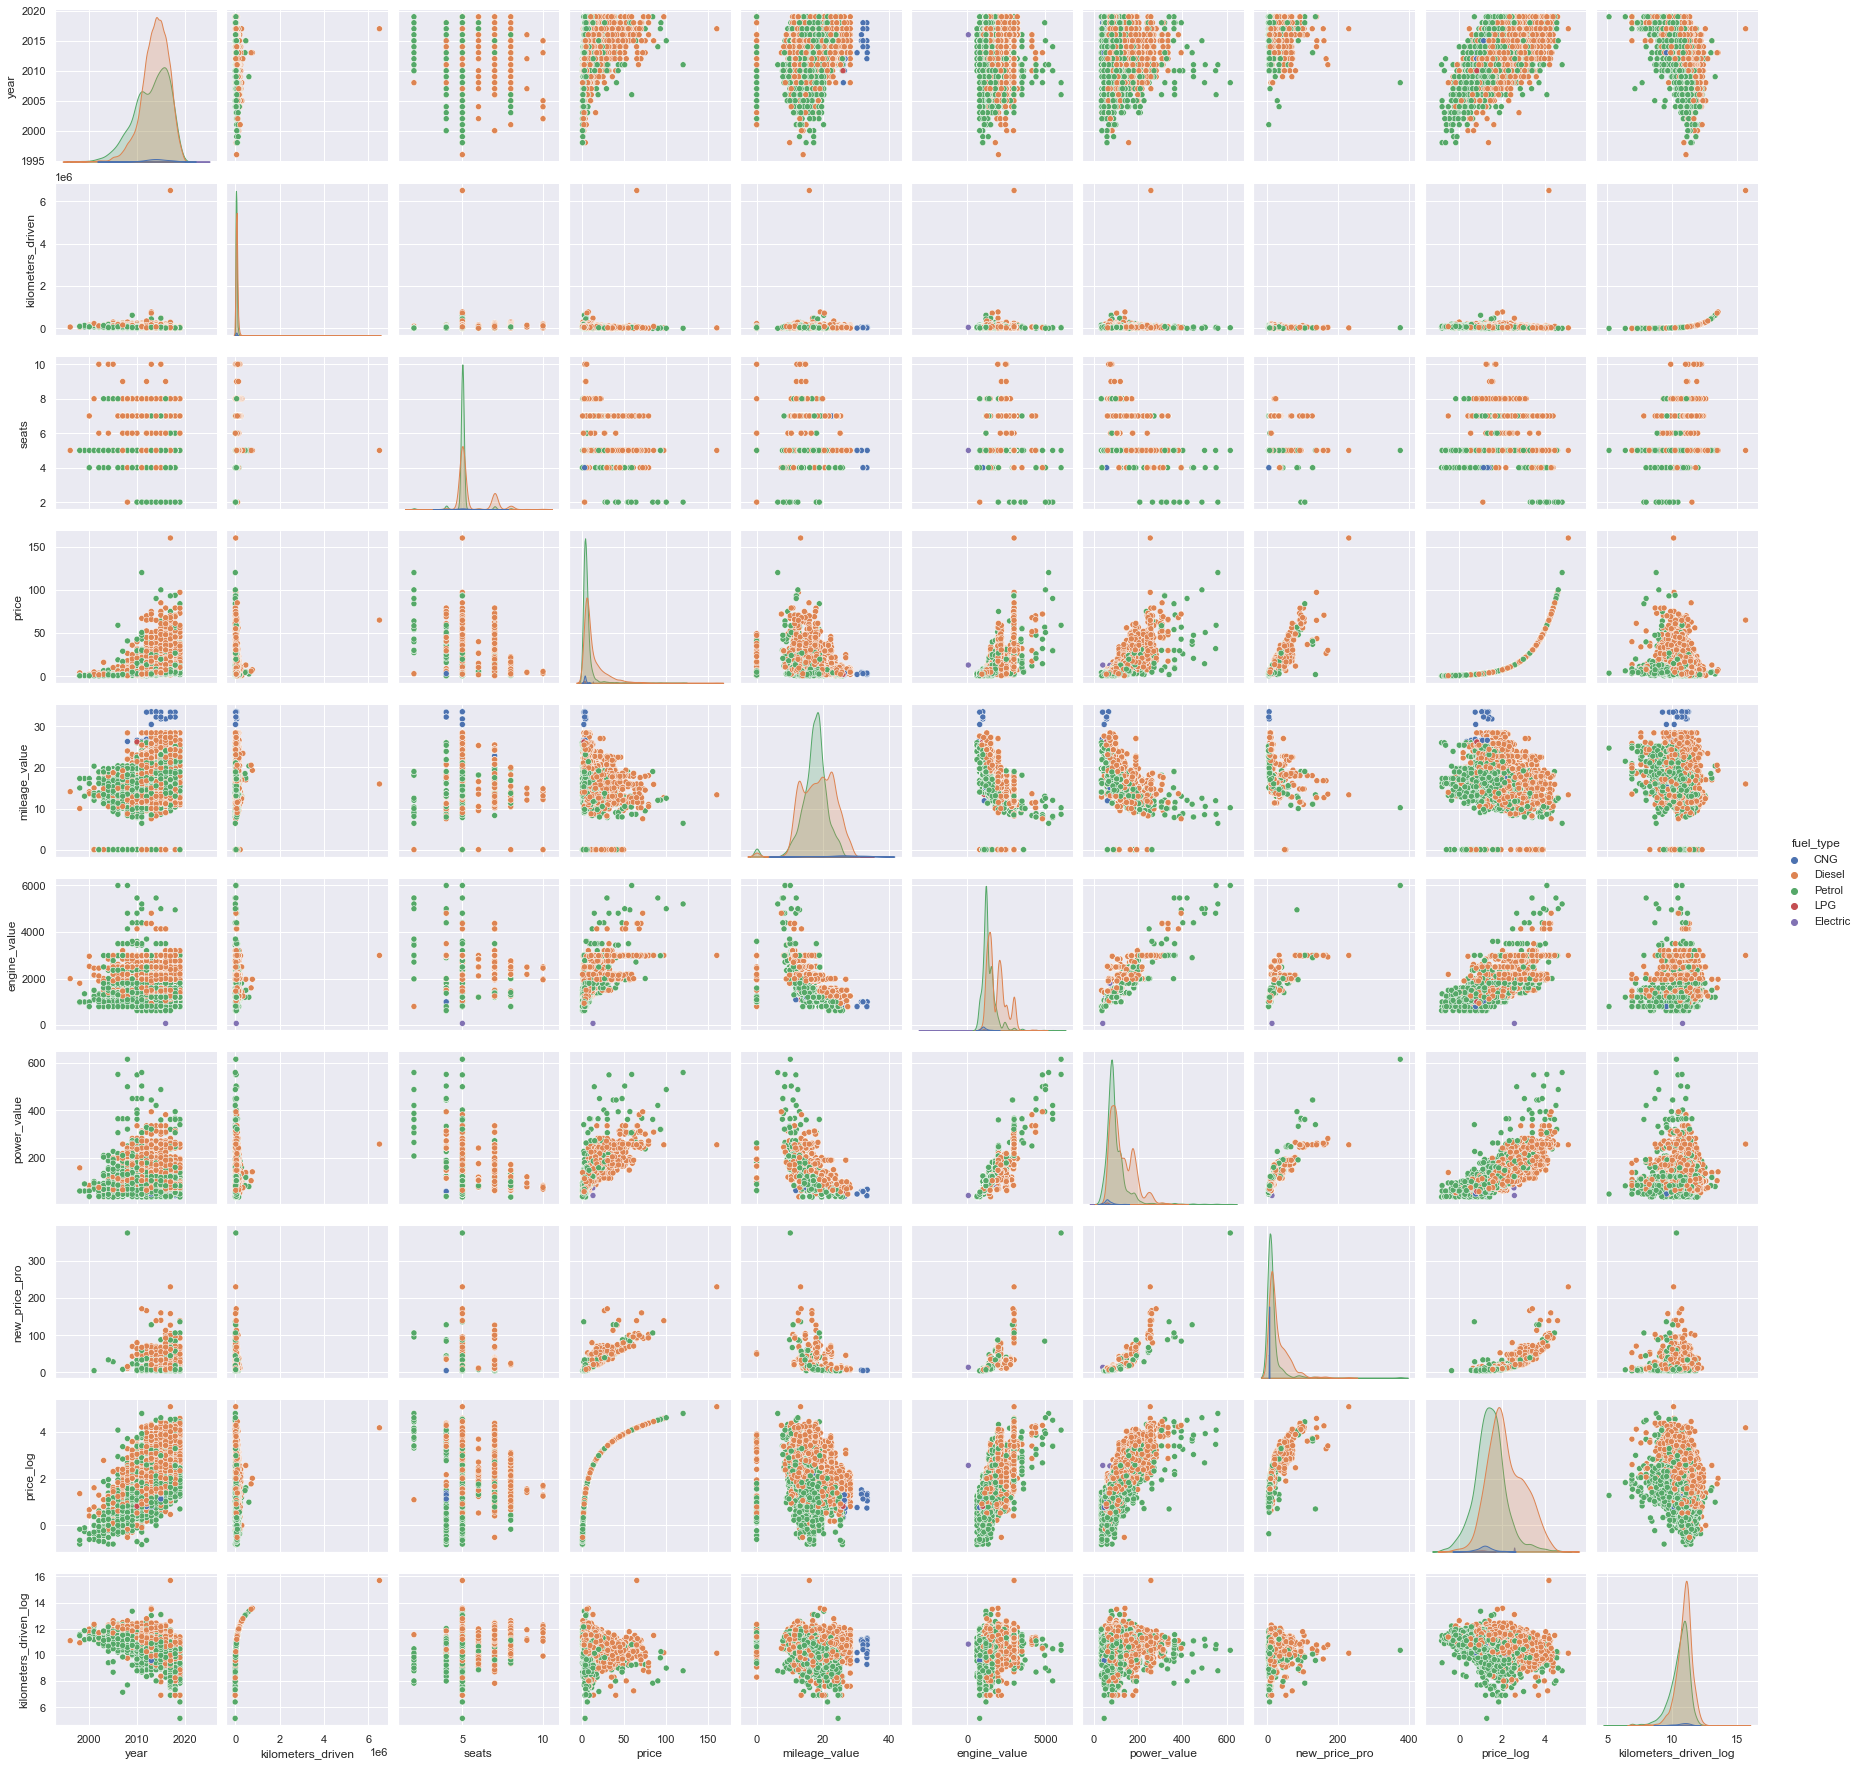

<IPython.core.display.Javascript object>

In [64]:
sns.pairplot(data=data, hue="fuel_type")

### Observations on the pair plot

- Pirce has a linear +ve correrlation with year, newer the car higher the pirce
- Kms driven does not have any relationship with price
- most of the cars are 5 seater, there are 8 and 10 seater cars as well
- power value and engine displacement value price have a linear relationship 
- new_price is correlated to used car price in a positive way as expected
- CNG cars can be considered as outliers

### Varitation of price with some variable

In [65]:
data.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,NaN,maruti,wagon,0.559616,11.184421
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,NaN,hyundai,creta,2.525729,10.621327
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61,honda,jazz,1.504077,10.736397
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,NaN,maruti,ertiga,1.791759,11.373663
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,NaN,audi,a4,2.875822,10.613246


<IPython.core.display.Javascript object>

<AxesSubplot:xlabel='location', ylabel='price_log'>

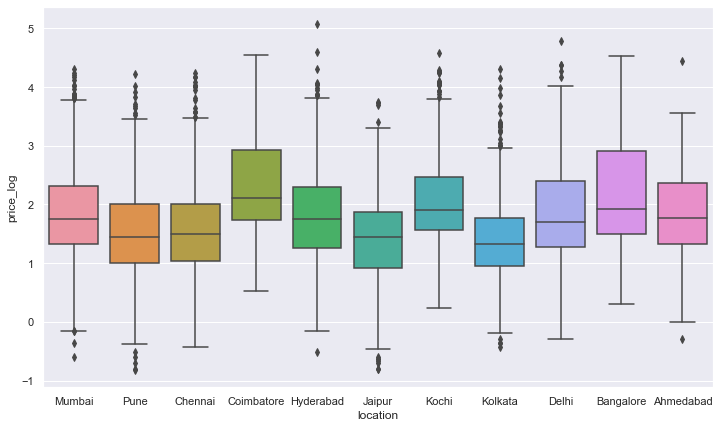

<IPython.core.display.Javascript object>

In [66]:
plt.figure(figsize=(12, 7))
sns.boxplot(x="location", y="price_log", data=data)

<AxesSubplot:xlabel='transmission', ylabel='price_log'>

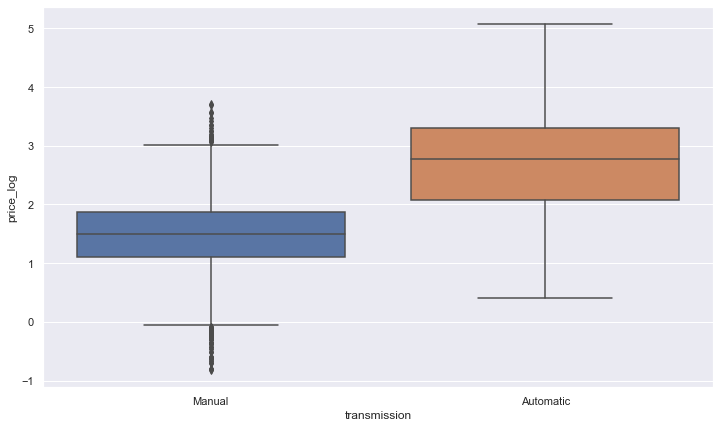

<IPython.core.display.Javascript object>

In [67]:
plt.figure(figsize=(12, 7))
sns.boxplot(x="transmission", y="price_log", data=data)

# the price is higher for used cars with automatic transmission

## Missingness in data

In [68]:
data.isnull().sum()

name                        0
location                    0
year                        0
kilometers_driven           0
fuel_type                   0
transmission                0
owner_type                  0
seats                      53
price                    1233
mileage_value               2
engine_value               46
power_value               175
new_price_pro            6246
brand                       0
model_name                  0
price_log                1233
kilometers_driven_log       0
dtype: int64

<IPython.core.display.Javascript object>

In [69]:
data[data["seats"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
194,Honda City 1.5 GXI,Ahmedabad,2007,60006,Petrol,Manual,First,NaN,2.95,0.00,NaN,NaN,NaN,honda,city,1.081805,11.002200
208,Maruti Swift 1.3 VXi,Kolkata,2010,42001,Petrol,Manual,First,NaN,2.11,16.10,NaN,NaN,NaN,maruti,swift,0.746688,10.645449
229,Ford Figo Diesel,Bangalore,2015,70436,Diesel,Manual,First,NaN,3.60,0.00,1498.0,99.0,NaN,ford,figo,1.280934,11.162460
733,Maruti Swift 1.3 VXi,Chennai,2006,97800,Petrol,Manual,Third,NaN,1.75,16.10,NaN,NaN,NaN,maruti,swift,0.559616,11.490680
749,Land Rover Range Rover 3.0 D,Mumbai,2008,55001,Diesel,Automatic,Second,NaN,26.50,0.00,NaN,NaN,NaN,land,rover,3.277145,10.915107
1294,Honda City 1.3 DX,Delhi,2009,55005,Petrol,Manual,First,NaN,3.20,12.80,NaN,NaN,NaN,honda,city,1.163151,10.915179
1327,Maruti Swift 1.3 ZXI,Hyderabad,2015,50295,Petrol,Manual,First,NaN,5.80,16.10,NaN,NaN,NaN,maruti,swift,1.757858,10.825661
1385,Honda City 1.5 GXI,Pune,2004,115000,Petrol,Manual,Second,NaN,1.50,0.00,NaN,NaN,NaN,honda,city,0.405465,11.652687
1460,Land Rover Range Rover Sport 2005 2012 Sport,Coimbatore,2008,69078,Petrol,Manual,First,NaN,40.88,0.00,NaN,NaN,NaN,land,rover,3.710641,11.142992
1917,Honda City 1.5 EXI,Jaipur,2005,88000,Petrol,Manual,Second,NaN,1.70,13.00,1493.0,100.0,NaN,honda,city,0.530628,11.385092


<IPython.core.display.Javascript object>

In [70]:
# we need to impute these values by using brand and model name

data.groupby(["brand", "model_name"], as_index=False)["seats"].median()

,brand,model_name,seats
0,ambassador,classic,5.0
1,audi,a3,5.0
2,audi,a4,5.0
3,audi,a6,5.0
4,audi,a7,5.0
...,...,...,...
217,volvo,s60,5.0
218,volvo,s80,5.0
219,volvo,v40,5.0
220,volvo,xc60,5.0


<IPython.core.display.Javascript object>

In [71]:
data["seats"] = data.groupby(["brand", "model_name"], as_index=False)[
    "seats"
].transform(lambda x: x.fillna(x.median()))

<IPython.core.display.Javascript object>

In [72]:
data[data["seats"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
2369,Maruti Estilo LXI,Chennai,2008,56000,Petrol,Manual,Second,NaN,1.50,19.5,1061.0,NaN,NaN,maruti,estilo,0.405465,10.933107
3882,Maruti Estilo LXI,Kolkata,2010,40000,Petrol,Manual,Second,NaN,2.50,19.5,1061.0,NaN,NaN,maruti,estilo,0.916291,10.596635
5893,Maruti Estilo LXI,Chennai,2008,51000,Petrol,Manual,Second,NaN,1.75,19.5,1061.0,NaN,NaN,maruti,estilo,0.559616,10.839581


<IPython.core.display.Javascript object>

In [73]:
data["seats"] = data["seats"].fillna(5.0)  # maruti estilo is a 5 seater car

<IPython.core.display.Javascript object>

In [74]:
data[data["seats"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log


<IPython.core.display.Javascript object>

In [75]:
data.isnull().sum()

name                        0
location                    0
year                        0
kilometers_driven           0
fuel_type                   0
transmission                0
owner_type                  0
seats                       0
price                    1233
mileage_value               2
engine_value               46
power_value               175
new_price_pro            6246
brand                       0
model_name                  0
price_log                1233
kilometers_driven_log       0
dtype: int64

<IPython.core.display.Javascript object>

In [76]:
col_list = ["mileage_value", "engine_value", "power_value", "new_price_pro"]

for cols in col_list:
    data[cols] = data.groupby(["brand"])[cols].transform(lambda x: x.fillna(x.median()))

<IPython.core.display.Javascript object>

In [77]:
data.isnull().sum()

name                        0
location                    0
year                        0
kilometers_driven           0
fuel_type                   0
transmission                0
owner_type                  0
seats                       0
price                    1233
mileage_value               0
engine_value                0
power_value                 2
new_price_pro             159
brand                       0
model_name                  0
price_log                1233
kilometers_driven_log       0
dtype: int64

<IPython.core.display.Javascript object>

In [78]:
data[data["power_value"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
915,Smart Fortwo CDI AT,Pune,2008,103000,Diesel,Automatic,Second,2.0,3.0,0.0,799.0,NaN,NaN,smart,fortwo,1.098612,11.542484
6216,Hindustan Motors Contessa 2.0 DSL,Pune,1996,65000,Diesel,Manual,Second,5.0,NaN,14.1,1995.0,NaN,NaN,hindustan,motors,NaN,11.082143


<IPython.core.display.Javascript object>

In [79]:
data["power_value"] = data["power_value"].fillna(data["power_value"].median())

<IPython.core.display.Javascript object>

In [80]:
data[data["power_value"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log


<IPython.core.display.Javascript object>

In [81]:
data[data["new_price_pro"].isnull()]

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log
145,Chevrolet Beat LT Option,Pune,2014,38800,Petrol,Manual,First,5.0,2.85,18.60,1199.0,76.80,NaN,chevrolet,beat,1.047319,10.566176
179,Chevrolet Beat Diesel LT,Jaipur,2012,88000,Diesel,Manual,First,5.0,1.50,25.44,936.0,57.60,NaN,chevrolet,beat,0.405465,11.385092
183,Chevrolet Optra Magnum 1.6 LS BS3,Jaipur,2007,118500,Petrol,Manual,First,5.0,1.25,12.90,1598.0,102.50,NaN,chevrolet,optra,0.223144,11.682668
231,Chevrolet Beat LT,Kochi,2016,60813,Petrol,Manual,Second,5.0,3.32,18.60,1199.0,76.80,NaN,chevrolet,beat,1.199965,11.015559
240,Chevrolet Beat Diesel LT,Mumbai,2013,74000,Diesel,Manual,First,5.0,2.65,25.44,936.0,57.60,NaN,chevrolet,beat,0.974560,11.211820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7111,Chevrolet Enjoy Petrol LTZ 7 Seater,Mumbai,2013,39000,Petrol,Manual,First,7.0,NaN,13.70,1399.0,98.82,NaN,chevrolet,enjoy,NaN,10.571317
7136,Chevrolet Spark 1.0 PS,Jaipur,2010,6512,Petrol,Manual,First,5.0,NaN,16.00,995.0,63.00,NaN,chevrolet,spark,NaN,8.781402
7141,Chevrolet Enjoy 1.4 LTZ 8,Pune,2016,67000,Petrol,Manual,First,8.0,NaN,13.70,1399.0,98.79,NaN,chevrolet,enjoy,NaN,11.112448
7223,Chevrolet Captiva LT,Kochi,2011,99120,Diesel,Manual,First,7.0,NaN,11.50,1991.0,147.90,NaN,chevrolet,captiva,NaN,11.504087


<IPython.core.display.Javascript object>

In [82]:
data["new_price_pro"].median()

11.105

<IPython.core.display.Javascript object>

In [83]:
data["new_price_pro"] = data["new_price_pro"].fillna(11.105)

<IPython.core.display.Javascript object>

In [84]:
data.isnull().sum()

name                        0
location                    0
year                        0
kilometers_driven           0
fuel_type                   0
transmission                0
owner_type                  0
seats                       0
price                    1233
mileage_value               0
engine_value                0
power_value                 0
new_price_pro               0
brand                       0
model_name                  0
price_log                1233
kilometers_driven_log       0
dtype: int64

<IPython.core.display.Javascript object>

In [85]:
data["price_log"] = data["price_log"].fillna(data["price_log"].median())

<IPython.core.display.Javascript object>

In [86]:
data.isnull().sum()

name                        0
location                    0
year                        0
kilometers_driven           0
fuel_type                   0
transmission                0
owner_type                  0
seats                       0
price                    1233
mileage_value               0
engine_value                0
power_value                 0
new_price_pro               0
brand                       0
model_name                  0
price_log                   0
kilometers_driven_log       0
dtype: int64

<IPython.core.display.Javascript object>

In [87]:
x = data.drop(["price_log", "price"], axis=1)
y = data["price_log"]

x = pd.get_dummies(
    x,
    columns=x.select_dtypes(["category", "object"]).columns.tolist(),
    drop_first=True,
)
x.head()

year  kilometers_driven  seats  mileage_value  engine_value  power_value  \
0  2010              72000    5.0          26.60         998.0        58.16   
1  2015              41000    5.0          19.67        1582.0       126.20   
2  2011              46000    5.0          18.20        1199.0        88.70   
3  2012              87000    7.0          20.77        1248.0        88.76   
4  2013              40670    5.0          15.20        1968.0       140.80   

   new_price_pro  kilometers_driven_log  name_Audi A3 35 TDI Attraction  \
0           7.87              11.184421                               0   
1           9.74              10.621327                               0   
2           8.61              10.736397                               0   
3           7.87              11.373663                               0   
4          55.61              10.613246                               0   

   name_Audi A3 35 TDI Premium  name_Audi A3 35 TDI Premium Plus  \
0                            0                                 0   
1                            0                                 0   
2                            0                                 0   
3                            0                                 0   
4                            0                                 0   

   name_Audi A3 35 TDI Technology  name_Audi A4 1.8 TFSI  \
0                               0                      0   
1                               0                      0   
2                               0                      0   
3                               0                      0   
4                               0                      0   

   name_Audi A4 1.8 TFSI Technology Edition  name_Audi A4 2.0 TDI  \
0                                         0                     0   
1                                         0                     0   
2                                         0                     0   
3                                         0                     0   
4                                         0                     0   

   name_Audi A4 2.0 TDI 177 Bhp Premium Plus  \
0                                          0   
1                                          0   
2                                          0   
3                                          0   
4                                          0   

   name_Audi A4 2.0 TDI 177 Bhp Technology Edition  \
0                                                0   
1                                                0   
2                                                0   
3                                                0   
4                                                0   

   name_Audi A4 2.0 TDI Celebration Edition  name_Audi A4 2.0 TDI Multitronic  \
0                                         0                                 0   
1                                         0                                 0   
2                                         0                                 0   
3                                         0                                 0   
4                                         0                                 0   

   name_Audi A4 2.0 TDI Premium Sport Limited Edition  name_Audi A4 2.0 TFSI  \
0                                                  0                       0   
1                                                  0                       0   
2                                                  0                       0   
3                                                  0                       0   
4                                                  0                       0   

   name_Audi A4 3.0 TDI Quattro  name_Audi A4 3.0 TDI Quattro Premium  \
0                             0                                     0   
1                             0                                     0   
2                             0                                     0   
3                 

<IPython.core.display.Javascript object>

In [88]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, random_state=40, test_size=0.3
)

<IPython.core.display.Javascript object>

In [89]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

LinearRegression()

<IPython.core.display.Javascript object>

In [90]:
coef_df = pd.DataFrame(
    np.append(lr_model.coef_, lr_model.intercept_),
    index=x_train.columns.tolist() + ["Intercept"],
    columns=["coefficient"],
)

coef_df

,coefficient
year,7.765084e-02
kilometers_driven,6.001644e-08
seats,9.145853e-03
mileage_value,-5.290525e-04
engine_value,-2.432438e-05
...,...
model_name_yeti,-1.983032e-01
model_name_z4,1.123187e+00
model_name_zen,1.306490e-01
model_name_zest,3.651302e-01


<IPython.core.display.Javascript object>

# Model performance check
- We will check the model performance on the actual prices and not the log values.
- We will create a function that will convert the log prices to actual prices and then check the performance.
- We will be using metric functions defined in sklearn for RMSE, MAE, and R2.
- We will define a function to calculate MAPE and adjusted R2.
- The mean absolute percentage error (MAPE) measures the accuracy of predictions as a percentage, and can be calculated as the average absolute percent error for each predicted value minus actual values divided by actual values. It works best if there are no extreme values in the data and none of the actual values are 0.

In [91]:
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    # computing the actual prices by using the exponential function
    target = np.exp(target)
    pred = np.exp(pred)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

<IPython.core.display.Javascript object>

In [92]:
print("Trainning performance")
lr_model_perf_train = model_performance_regression(lr_model, x_train, y_train)
lr_model_perf_train

Trainning performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,3.43794,1.410277,0.880881,0.781047,16.916207


<IPython.core.display.Javascript object>

- Both rsquare and adj R-squared look good, which is an indication that we are able to explain 79% variation in the data
- The model is not underfitiing model

In [93]:
print("Test performance")
lr_model_perf_test = model_performance_regression(lr_model, x_test, y_test)
lr_model_perf_test

# model is not performing well on test data , but we can improve and work on it

Test performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,6.673511,2.970132,0.633472,6.735238,35.588499


<IPython.core.display.Javascript object>

- Mean absolute error indicates that 2.49 lakh price error is predicted
- MAPE of 27.02 on the test data indicates that the model can predict within ~27% of the used car price.
- The units of both RMSE and MAE are the same, Lakhs in this case. But RMSE is greater than MAE because it penalizes the outliers more.

### Current model seems to be underperfoming and probably curse of dimensionality has its effect

In [94]:
data.groupby(["brand", "model_name"])["new_price_pro"].mean().sort_values(
    ascending=False
)

brand    model_name 
bentley  flying         375.000000
         continental    375.000000
porsche  boxster        136.000000
         panamera       136.000000
         cayenne        136.000000
                           ...    
renault  pulse            4.930000
         scala            4.930000
         kwid             4.822273
datsun   redi             4.370000
         redi-go          4.130000
Name: new_price_pro, Length: 222, dtype: float64

<IPython.core.display.Javascript object>

In [95]:
data1 = data.copy()

<IPython.core.display.Javascript object>

In [96]:
data1["car_category"] = pd.cut(
    x=data["new_price_pro"],
    bins=[0, 15, 30, 50, 200],
    labels=["budget_friendly", "mid_range", "luxury_car", "ultra_luxury"],
)
data1.car_category.value_counts()

budget_friendly    5247
ultra_luxury       1070
mid_range           582
luxury_car          350
Name: car_category, dtype: int64

<IPython.core.display.Javascript object>

In [97]:
data1.head()

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,mileage_value,engine_value,power_value,new_price_pro,brand,model_name,price_log,kilometers_driven_log,car_category
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,7.87,maruti,wagon,0.559616,11.184421,budget_friendly
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,9.74,hyundai,creta,2.525729,10.621327,budget_friendly
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,8.61,honda,jazz,1.504077,10.736397,budget_friendly
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,7.87,maruti,ertiga,1.791759,11.373663,budget_friendly
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,55.61,audi,a4,2.875822,10.613246,ultra_luxury


<IPython.core.display.Javascript object>

In [98]:
data1.drop(["brand", "model_name"], axis=1, inplace=True)

<IPython.core.display.Javascript object>

In [99]:
x = data1.drop(["price_log", "price"], axis=1)
y = data1["price_log"]

x = pd.get_dummies(
    x,
    columns=x.select_dtypes(["category", "object"]).columns.tolist(),
    drop_first=True,
)
x.head()

x_train2, x_test2, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

print("Number of rows in train data =", x_train2.shape[0])
print("Number of rows in test data =", x_test2.shape[0])

Number of rows in train data = 5076
Number of rows in test data = 2176


<IPython.core.display.Javascript object>

In [100]:
lr_model_2 = LinearRegression()
lr_model_2.fit(x_train, y_train)

LinearRegression()

<IPython.core.display.Javascript object>

In [101]:
print("Trainning performance")
lr_model_2_perf_train = model_performance_regression(lr_model_2, x_train, y_train)
lr_model_2_perf_train

Trainning performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,8.879162,4.04539,0.258879,-0.362257,51.204445


<IPython.core.display.Javascript object>

In [102]:
print("Test performance")
lr_model_2_perf_test = model_performance_regression(lr_model_2, x_test, y_test)
lr_model_2_perf_test

Test performance


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,11.171707,5.904604,-0.189243,19.608665,83.086168


<IPython.core.display.Javascript object>

# Business Insights and Recommendations


- Cars with a lesser number of kilometers driven should be preferred.
- Some markets tend to have higher prices. Cars4U should focus more on these markets, and set up offices in these areas if needed.
- We will have to analyze the cost side of things before we can talk about profitability in the business. We should gather data regarding that.
- The next step post that would be to cluster different sets of data and see if we should make multiple models for different locations/car types